# Упражнения пункт 2.5

In [23]:
from numpy import sqrt, linspace
import matplotlib.pyplot as plt
import pandas as pd

### Упражнение 1

/tmp/ipykernel_15119/3556595977.py:5: RuntimeWarning: invalid value encountered in sqrt
  lambda x: -sqrt(x-1) + 0.5,      # убывающая с выпуклостью вверх
/tmp/ipykernel_15119/3556595977.py:6: RuntimeWarning: invalid value encountered in sqrt
  lambda x: sqrt(2.5-x) - 0.5      # убывающая с выпуклостью вниз


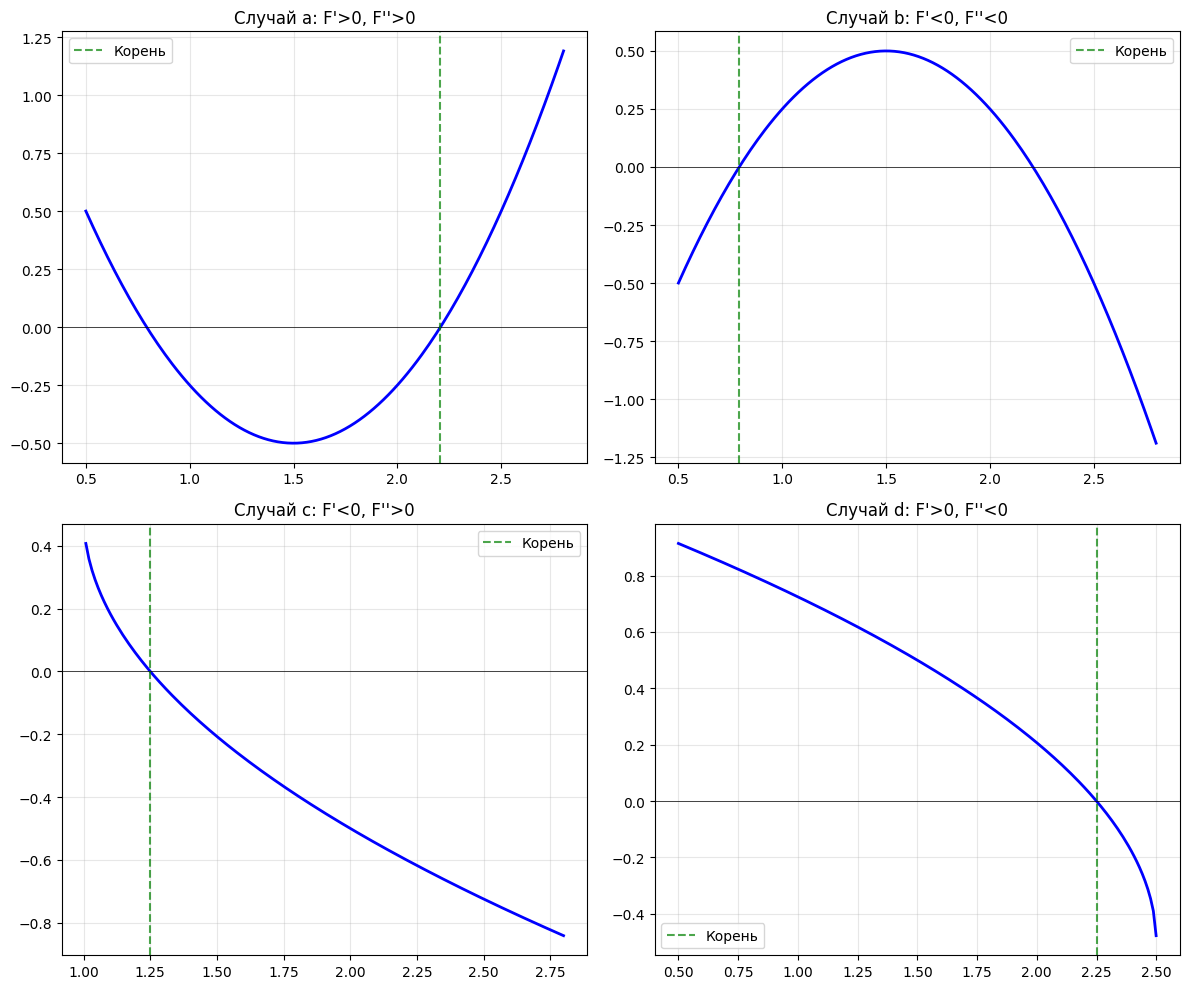

In [ ]:
# 4 разных случая
funcs = [
    lambda x: (x-1.5)**2 - 0.5,      # парабола ветвями вверх
    lambda x: -(x-1.5)**2 + 0.5,     # парабола ветвями вниз
    lambda x: -sqrt(x-1) + 0.5,      # убывающая с выпуклостью вверх
    lambda x: sqrt(2.5-x) - 0.5      # убывающая с выпуклостью вниз
]

# Заголовки для графиков для понимания
titles = ["F'>0, F''>0", "F'<0, F''<0", "F'<0, F''>0", "F'>0, F''<0"]
# Корни функции
roots = [1.5 + sqrt(0.5), 1.5 - sqrt(0.5), 1.25, 2.25]

# Визуализируем
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (f, title, root) in enumerate(zip(funcs, titles, roots)):
    x = linspace(0.5, 2.8, 200)
    y = f(x)
    
    axes[i].plot(x, y, 'b-', linewidth=2)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axvline(root, color='g', linestyle='--', alpha=0.7, label='Корень')
    axes[i].set_title(f'Случай {chr(97+i)}: {title}')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Упражнение 2

In [25]:
def f(x):
    return x**3 + 3*x**2 - 24*x + 1

def f1(x):
    return 3*x**2 + 6*x - 24

a, b = 0, 1
eps = 0.000001

# Начальные приближения
x_chord = a      # для метода хорд
x_tangent = b    # для метода касательных

data = []

for i in range(100):
    # Метод хорд
    x_chord_new = x_chord - f(x_chord) * (x_tangent - x_chord) / (f(x_tangent) - f(x_chord))
    
    # Метод касательных (Ньютона)
    x_tangent_new = x_tangent - f(x_tangent) / f1(x_tangent)
    
    diff = abs(x_chord_new - x_tangent_new)
    
    data.append({
        'Итерация': i + 1,
        'Метод хорд': x_chord_new,
        'Метод касательных': x_tangent_new,
        'Разница': diff
    })
    
    if diff < eps:
        root = (x_chord_new + x_tangent_new) / 2
        break
    
    x_chord, x_tangent = x_chord_new, x_tangent_new

# Создаем DataFrame
df = pd.DataFrame(data)

In [26]:
df

,Итерация,Метод хорд,Метод касательных,Разница
0,1,0.0500000000,-0.2666666667,0.3166666667
1,2,0.0421766095,0.0324813259,0.0096952836
2,3,0.0418894207,0.0418775134,0.0000119072
3,4,0.0418890660,0.0418890660,0.0000000000


In [27]:
print(f"\nКорень уравнения: {root:.10f}")
print(f"Значение функции: f({root:.10f}) = {f(root):.2e}")


Корень уравнения: 0.0418890660
Значение функции: f(0.0418890660) = 2.02e-10
